# Análise de impactos do teste de cupons

## Imports e Downloads dos dados

In [94]:
!pip install spicy

  Using cached spicy-0.16.0-py2.py3-none-any.whl (1.7 kB)



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import requests
import tarfile
import polars as pl
import os
import duckdb
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

# Visualização
sns.set_theme(style='ticks', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [ ]:
#===================
# Download dos dados
#===================

url_orders = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/order.json.gz" 
url_consumers = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/consumer.csv.gz" 
url_restaurants = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/restaurant.csv.gz" 
url_abtest = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/ab_test_ref.tar.gz" 

con = duckdb.connect()

# Teste A/B
response = requests.get(url_abtest, stream=True)

# with tarfile.open(fileobj=response.raw, mode="r:gz") as tar:
#     for member in tar.getmembers():
#         if member.isfile():
#             print(member.name)

# response = requests.get(url_abtest, stream=True)
# with tarfile.open("ab.tar.gz") as tar:
#     for member in tar:
#         if member.isfile() and not member.name.startswith(".") and member.name.endswith(".csv"):
#             print(member.name)
#             file = tar.extractfile(member)
#             df = pd.read_csv(file)


with tarfile.open(fileobj=BytesIO(response.raw.read()), mode="r:gz") as tar:
    for member in tar:
        if member.isfile() and not member.name.startswith(".") and member.name.endswith(".csv"):
            print(member.name)
            file = tar.extractfile(member)
            df_abtest = pd.read_csv(file)
#     for member in tar:
#         if member.name.endswith("ab_test_ref.csv"):
#             file = tar.extractfile(member)
#             df = pd.read_csv(file)
#             break

con.register("ab_test", df_abtest)

# Restaurantes
df_restaurants = pd.read_csv(url_restaurants, compression="gzip")
con.register("restaurants", df_restaurants)

# Consumers
df_customers = pd.read_csv(url_consumers,compression="gzip")
con.register("customers", df_customers)

# Orders
chunks = pd.read_json(
    url_orders,
    lines=True,
    chunksize=10000,  # diminui o chunk!
    compression="gzip"
)

orders_dir = "data/orders"

for i, chunk in enumerate(chunks):
    chunk.to_parquet(
        f"{orders_dir}/orders_part_{i}.parquet",
        engine="pyarrow",
        index=False
    )

con.execute("""
CREATE VIEW orders AS 
SELECT * FROM '../data/orders/*.parquet'
""")


In [3]:
#===================
# Download dos dados
#===================

url_orders = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/order.json.gz" 
url_consumers = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/consumer.csv.gz" 
url_restaurants = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/restaurant.csv.gz" 
url_abtest = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/ab_test_ref.tar.gz" 

con = duckdb.connect()

# Teste A/B
response = requests.get(url_abtest, stream=True)

# with tarfile.open(fileobj=response.raw, mode="r:gz") as tar:
#     for member in tar.getmembers():
#         if member.isfile():
#             print(member.name)

# response = requests.get(url_abtest, stream=True)
# with tarfile.open("ab.tar.gz") as tar:
#     for member in tar:
#         if member.isfile() and not member.name.startswith(".") and member.name.endswith(".csv"):
#             print(member.name)
#             file = tar.extractfile(member)
#             df = pd.read_csv(file)


with tarfile.open(fileobj=BytesIO(response.raw.read()), mode="r:gz") as tar:
    for member in tar:
        if member.isfile() and not member.name.startswith(".") and member.name.endswith(".csv"):
            # print(member.name)
            file = tar.extractfile(member)
            df_abtest = pd.read_csv(file)
#     for member in tar:
#         if member.name.endswith("ab_test_ref.csv"):
#             file = tar.extractfile(member)
#             df = pd.read_csv(file)
#             break

con.register("ab_test", df_abtest)

# Restaurantes
df_restaurants = pd.read_csv(url_restaurants, compression="gzip")
con.register("restaurants", df_restaurants)

# Consumers
df_customers = pd.read_csv(url_consumers,compression="gzip")
con.register("customers", df_customers)

# # Orders
# chunks = pd.read_json(
#     url_orders,
#     lines=True,
#     chunksize=10000,  # diminui o chunk!
#     compression="gzip"
# )

# orders_dir = "data/orders"

# for i, chunk in enumerate(chunks):
#     chunk.to_parquet(
#         f"{orders_dir}/orders_part_{i}.parquet",
#         engine="pyarrow",
#         index=False
#     )

con.execute("""
CREATE VIEW orders AS 
SELECT * FROM '../data/orders/*.parquet'
""")


## Análise exploratória

In [ ]:
#===============================
# Usuários participando do teste
#===============================

df_customers_test = df_customers.merge(
    df_abtest,
    on='customer_id',
    how='left'
)

df_customers_test.groupby("is_target").agg(
    count_customers=("customer_id","count")
).reset_index()

,is_target,count_customers
0,control,360413
1,target,445743


In [ ]:
#==============================
# Quantidade de usuários ativos
#==============================

df_customers_test.groupby(["is_target","active"]).agg(
    count_customers=("customer_id","count")
).reset_index()

,is_target,active,count_customers
0,control,False,713
1,control,True,359700
2,target,False,882
3,target,True,444861


In [ ]:
#===============================
# Usuários com 1 ou mais pedidos
#===============================
df_conv = con.execute("""
    WITH
    ORDERS_PER_USER as (
    SELECT 
        c.customer_id,
        COUNT(o.order_id) orders_amount
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1
                
    )
    SELECT 
        a.is_target,
        case when coalesce(orders_amount,0) > 0 then 1 else 0 end as fl_order,
        COUNT(c.customer_id) as count_customers
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN ORDERS_PER_USER o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1,2
""").fetchdf()

display(df_conv)


,is_target,fl_order,count_customers
0,control,1,359700
1,target,1,444861


In [141]:
#===============================
# Usuários com 1 ou mais pedidos
#===============================
df_conv = con.execute("""
    SELECT 
        AVG(order_total_amount) orders_amount,
        count(o.order_id) qtd,
        count(c.customer_id) c,
        count(distinct c.customer_id) cd              
    FROM orders o
    left join customers c ON c.customer_id = o.customer_id
""").fetchdf()

display(df_conv)

,orders_amount,qtd,c,cd
0,47.900055,3670826,3661050,806156


In [142]:
#====================
# VALORES DOS PEDIDOS
#====================
df_ab_orders = con.execute("""
    SELECT 
        COUNT(o.order_id) as orders_amount,
        SUM(o.order_total_amount) / COUNT(distinct c.customer_id) as avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user,
        COUNT(o.order_id) / COUNT(distinct c.customer_id) as orders_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.active
""").fetchdf()

display(df_ab_orders)

,orders_amount,avg_total_amount_per_user,avg_order_amount_per_user,orders_per_user
0,3652136,216.991019,72.121626,4.53929


In [144]:
72.12*1000000

72120000.0

In [ ]:
#====================
# VALORES DOS PEDIDOS
#====================
df_ab_orders = con.execute("""
    SELECT 
        a.is_target,
        COUNT(o.order_id) as orders_amount,
        SUM(o.order_total_amount) / COUNT(distinct c.customer_id) as avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user,
        COUNT(o.order_id) / COUNT(distinct c.customer_id) as orders_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1
""").fetchdf()

display(df_ab_orders)


,is_target,orders_amount,avg_order_amount_per_user,avg_amount_per_user,orders_per_user
0,control,1521612,202.600831,72.289970,4.230225
1,target,2130524,228.626453,72.001484,4.789190


In [ ]:
#======================
# Atividade por usuário
#======================
df_order_user = con.execute("""
    with
    ORDERS AS (
        SELECT 
            a.is_target,
            c.customer_id,
            COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user
        FROM customers c
        LEFT JOIN ab_test a ON c.customer_id = a.customer_id
        LEFT JOIN orders o ON c.customer_id = o.customer_id 
        WHERE c.active
        GROUP BY 1,2
    )
    SELECT 
        is_target,
        case 
            when orders_per_user  = 0 then '0'
            when orders_per_user  = 1 then '1'
            when orders_per_user  = 2 then '2'
            when orders_per_user <= 5 then '3 a 5'
            when orders_per_user <= 10 then '6 a 10'
            when orders_per_user  > 10 then '> 10'
            else 'g. Sem info'
            end as orders_per_user_range,
        COUNT(customer_id) AS customers_amount
    FROM ORDERS
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

df_order_user["percentual"] = round(
    (
    df_order_user["customers_amount"] /
    df_order_user.groupby("is_target")["customers_amount"].transform("sum")
    ) * 100
,2)

#======= Visualização =======
df_pivot = df_order_user.pivot(
    index="orders_per_user_range",
    columns="is_target",
    values="percentual"
)

ordem = [
    '1',
    '2',
    '3 a 5',
    '6 a 10',
    '> 10'
]

df_pivot = df_pivot.loc[ordem]

plt.figure()

ax = df_pivot.plot(kind='bar')


# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom"
        )

plt.title("Distribuição de Pedidos por Usuário (Control vs Target)")
plt.xlabel("Pedidos")
plt.ylabel("Percentual de clientes (%)")
plt.xticks(rotation=45)

plt.show()

In [66]:
#==================================
# Top restaurantes com mais pedidos
#==================================
df_ab_orders = con.execute("""
    SELECT 
        a.is_target,
        r.id,
        r.price_range,
        r.average_ticket,    
        r.delivery_time,
        r.minimum_order_value, 
        COUNT(distinct o.customer_id) as count_d_customers,                   
        COUNT(o.order_id) as count_orders
    FROM restaurants r
    LEFT JOIN orders o ON r.id = o.merchant_id
    LEFT JOIN ab_test a ON o.customer_id = a.customer_id
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    WHERE c.active and a.is_target = 'target'
    GROUP BY 1,2,3,4,5,6
    ORDER BY 8 DESC
""").fetchdf()

display(df_ab_orders)


,is_target,id,price_range,average_ticket,delivery_time,minimum_order_value,count_d_customers,count_orders
0,target,9334a66b3f7ef0587f5154944245b128853011662c7784...,2,40.0,0.0,4.99,3297,9827
1,target,59bd4c9e62ac85fecd47b92ca4e82a0b3682fcaa084e64...,1,30.0,50.0,20.00,1745,6344
2,target,8e35ea4e600facfb8763d86e403b849977f876729c1446...,4,80.0,40.0,50.00,2163,5498
3,target,b98480b6471b6c67e88634bb32c73e8d82962b8ae527e4...,3,60.0,0.0,23.90,1820,5323
4,target,dba4729cc5371933e008eedeba114f17a5f6c27b039f97...,1,30.0,50.0,0.00,1693,5020
...,...,...,...,...,...,...,...,...
7222,target,c2e394eb453c57d848dc6135f8253fefabaa5de10b45ad...,1,30.0,25.0,25.00,1,1
7223,target,964def24b1d9fd5bc6f4a4f6b572db79e0f9e12b363088...,1,30.0,50.0,0.00,1,1
7224,target,d439fbe33373249706f9bc3f7f65ab45a7e8690eaf9487...,3,60.0,45.0,10.00,1,1
7225,target,27a4c8c3ac37f7eafb378e4e7ab969e9ce874f61d8ef03...,3,60.0,60.0,0.00,1,1


In [67]:
#==================================
# Top restaurantes com mais pedidos
#==================================
df_ab_orders = con.execute("""
    SELECT 
        a.is_target,
        r.id,
        r.price_range,
        r.average_ticket,    
        r.delivery_time,
        r.minimum_order_value, 
        COUNT(distinct o.customer_id) as count_d_customers,                   
        COUNT(o.order_id) as count_orders
    FROM restaurants r
    LEFT JOIN orders o ON r.id = o.merchant_id
    LEFT JOIN ab_test a ON o.customer_id = a.customer_id
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    WHERE c.active and a.is_target = 'control'
    GROUP BY 1,2,3,4,5,6
    ORDER BY 8 DESC
""").fetchdf()

display(df_ab_orders)


,is_target,id,price_range,average_ticket,delivery_time,minimum_order_value,count_d_customers,count_orders
0,control,9334a66b3f7ef0587f5154944245b128853011662c7784...,2,40.0,0.0,4.99,2372,6914
1,control,59bd4c9e62ac85fecd47b92ca4e82a0b3682fcaa084e64...,1,30.0,50.0,20.00,1272,4659
2,control,8e35ea4e600facfb8763d86e403b849977f876729c1446...,4,80.0,40.0,50.00,1622,3874
3,control,5fb0f99afff413461dc30ee013cdda640799cfdbf33001...,3,60.0,0.0,25.00,1475,3713
4,control,dba4729cc5371933e008eedeba114f17a5f6c27b039f97...,1,30.0,50.0,0.00,1231,3676
...,...,...,...,...,...,...,...,...
7190,control,e15511eeda939db747f93b6eede77a6bf4e44549d79b33...,2,40.0,40.0,30.00,1,1
7191,control,2d744cc7da57a8af2ff2321cdfe2092e6d960f0493b392...,5,81.0,60.0,20.00,1,1
7192,control,f392d030127b565263197bff089be8a63fa839989e320a...,2,40.0,0.0,0.00,1,1
7193,control,5e4fe02b8fdde857a11470d866def5d3449e97d5847dca...,2,40.0,20.0,12.90,1,1


In [ ]:
#=================
# Tempo de entrega
#=================
df_delivery_time = con.execute("""
    SELECT 
        is_target,
        case
            when r.delivery_time < 1 then 'f. Sem informação'
            when r.delivery_time <= 15 then 'a. Até 10 minutos' 
            when r.delivery_time <= 30 then 'a. Até 30 minutos'
            when r.delivery_time <= 45 then 'b. 20-45 minutos'
            when r.delivery_time <= 60 then 'c. 45-60 minutos'
            when r.delivery_time <= 90 then 'd. 60-90 minutos'
            else 'f. Sem informação'
            end as delivery_time_range,
        count(r.id) as count_restaurants,
        count(o.order_id) as count_orders
    FROM restaurants r  
    LEFT JOIN orders o ON r.id = o.merchant_id
    LEFT JOIN ab_test a ON o.customer_id = a.customer_id
    group by 1,2 
    order by 1,2          
""").fetchdf()

print(df_delivery_time)

   is_target delivery_time_range  count_restaurants  count_orders
0    control   a. Até 10 minutos              38085         38085
1    control   a. Até 30 minutos             179706        179706
2    control    b. 20-45 minutos             290938        290938
3    control    c. 45-60 minutos             259138        259138
4    control    d. 60-90 minutos              37035         37035
5    control   f. Sem informação             720674        720674
6     target   a. Até 10 minutos              53551         53551
7     target   a. Até 30 minutos             252905        252905
8     target    b. 20-45 minutos             405998        405998
9     target    c. 45-60 minutos             362898        362898
10    target    d. 60-90 minutos              53169         53169
11    target   f. Sem informação            1008224       1008224
12       NaN   a. Até 10 minutos                273           273
13       NaN   a. Até 30 minutos                996           996
14       N

df_delivery_time

In [120]:
#==============================
# Faixa de preço do restaurante
#==============================

df_price_range = con.execute("""
    SELECT 
        is_target,
        enabled,
        price_range,         
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) AS total_orders,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    LEFT JOIN restaurants r ON o.merchant_id = r.id
    WHERE active           
    GROUP BY 1,2,3
""").fetchdf()

#======= Visualização =======
df_pivot = df_price_range.pivot(
    index="price_range",
    columns="is_target",
    values="orders_per_user"
)

plt.figure()

ax = df_pivot.plot(kind='bar')

# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom"
        )

plt.xlabel("Price range")
plt.ylabel("Orders per user")
plt.xticks(rotation=45)

plt.show()

ValueError: Index contains duplicate entries, cannot reshape

<Figure size 1680x720 with 0 Axes>

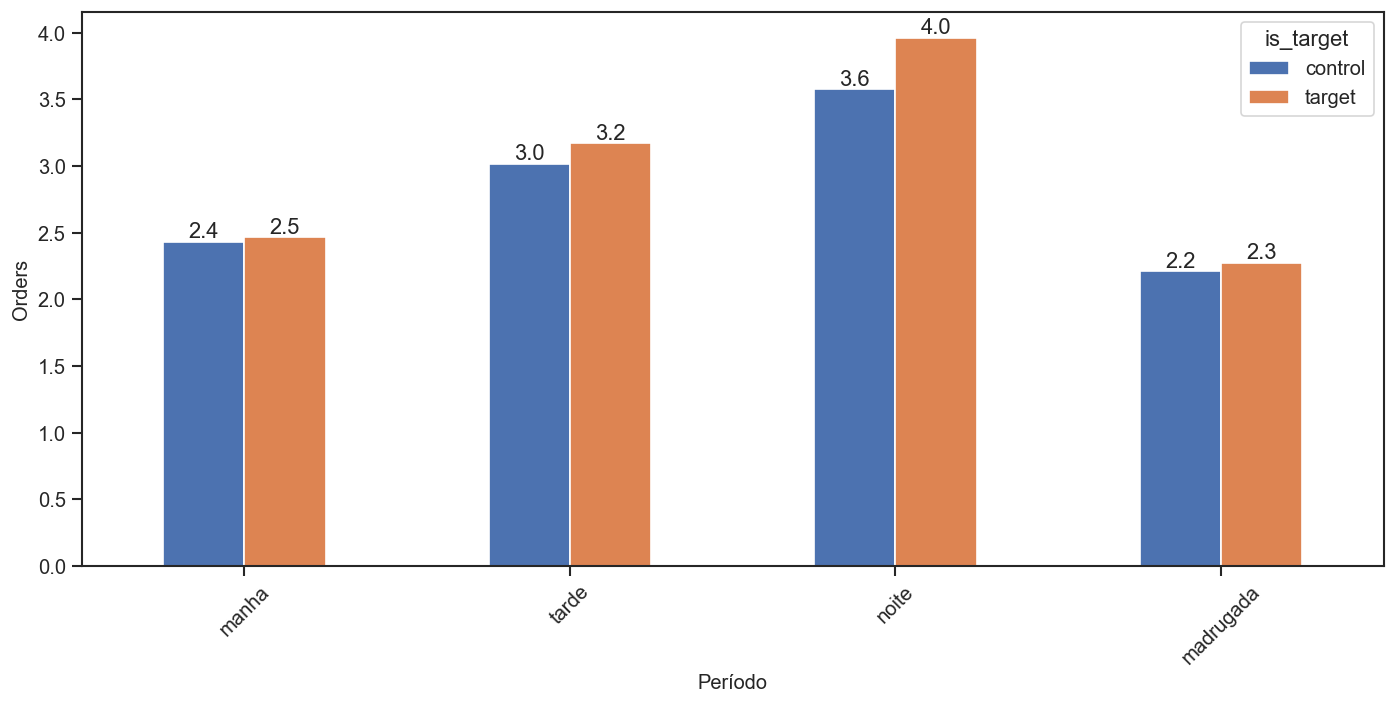

In [121]:
#===================
# Período de entrega
#===================

df_day_time = con.execute("""
    SELECT 
        a.is_target,
        case
            when EXTRACT(HOUR FROM order_created_at) < 5 THEN 'madrugada'
            when EXTRACT(HOUR FROM order_created_at) < 12 THEN 'manha'
            when EXTRACT(HOUR FROM order_created_at) < 18 THEN 'tarde'
            else 'noite'
            end as time_range,
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id 
    LEFT JOIN restaurants r ON o.merchant_id = r.id
    WHERE c.active
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

df_pivot = df_day_time.pivot(
    index="time_range",
    columns="is_target",
    values="orders_per_user"
)

ordem = [
    'manha',
    'tarde',
    'noite',
    'madrugada'
]

df_pivot = df_pivot.loc[ordem]

plt.figure()

ax = df_pivot.plot(kind='bar')

# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom"
        )

plt.xlabel("Período")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

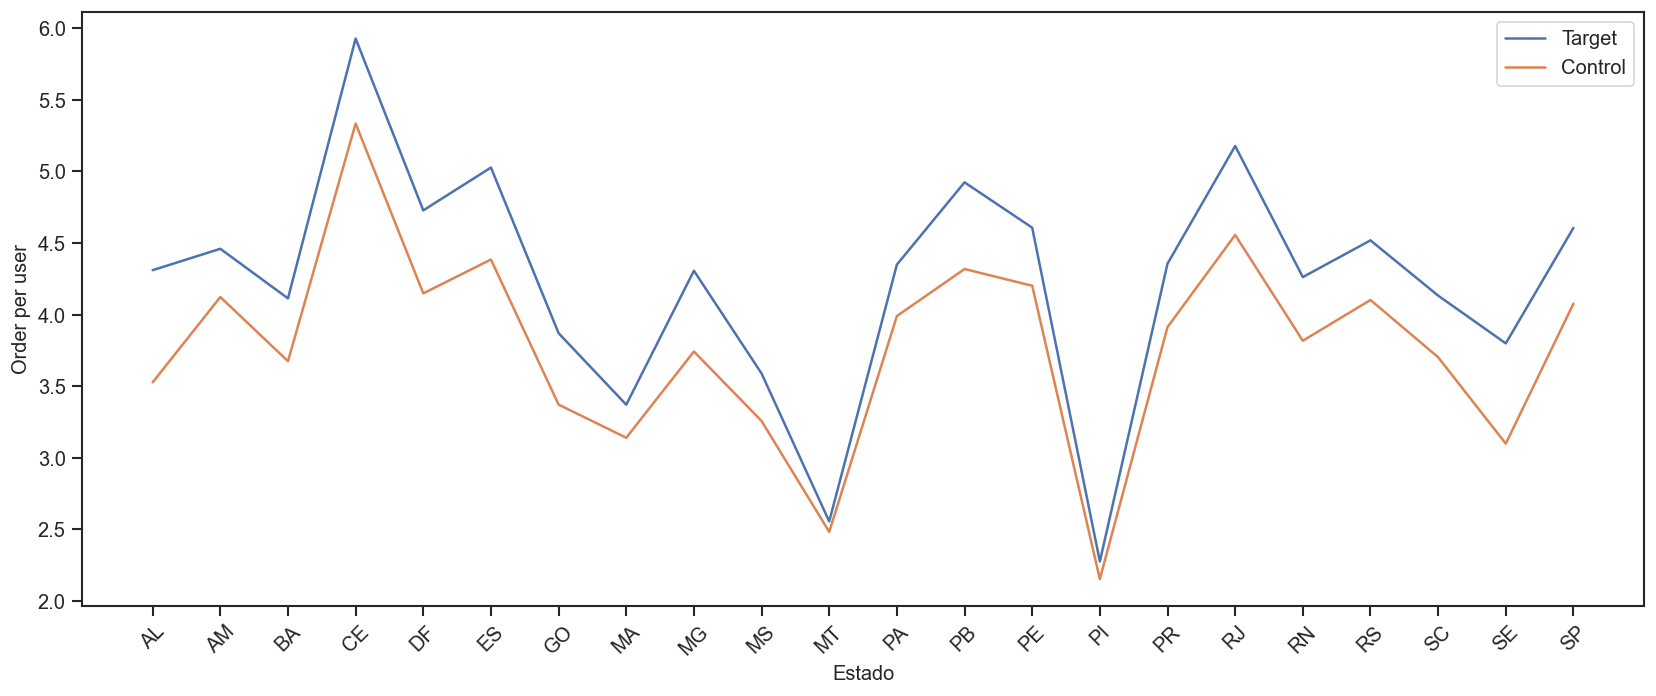

In [123]:
#===================
# Pedidos por estado
#===================

df_state = con.execute("""
    SELECT 
        a.is_target,
        o.delivery_address_state,
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id 
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

df_state = df_state[df_state["delivery_address_state"] != "AC"] # amostra muito pequena, pode sujar a análise

df_target = df_state[df_state["is_target"] == "target"]
df_control = df_state[df_state["is_target"] == "control"]

plt.figure()

plt.plot(
    df_target["delivery_address_state"],
    df_target["orders_per_user"],
    label = "Target"
)

plt.plot(
    df_control["delivery_address_state"],
    df_control["orders_per_user"],

    label = "Control"
)

plt.xlabel("Estado")
plt.ylabel("Order per user")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1680x720 with 0 Axes>

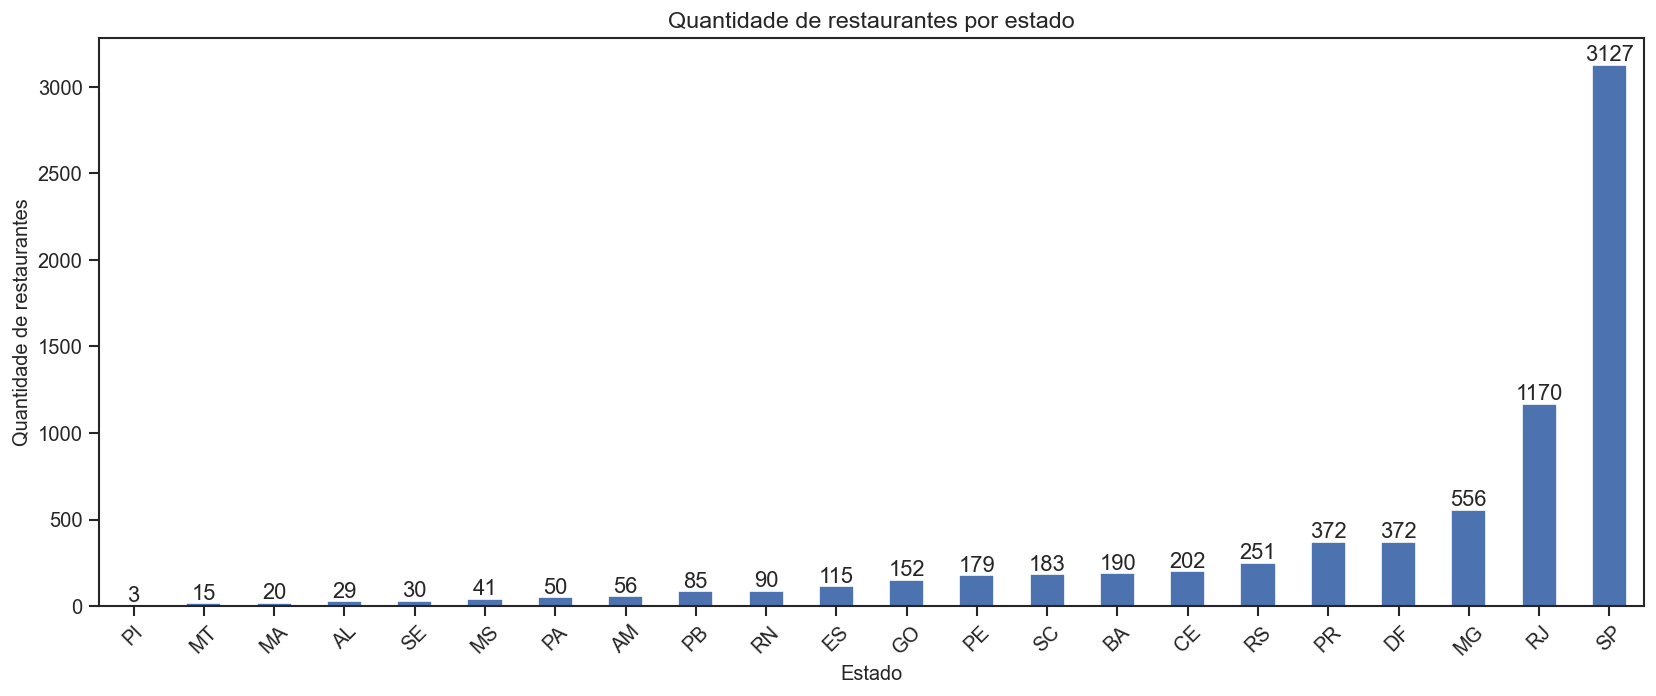

In [133]:
#========================
# Restaurantes por estado
#========================

df_restaurantes_per_state = df_restaurants.groupby("merchant_state").agg(
    count_restaurants=("id","count")
).reset_index().sort_values(by="count_restaurants")

df_restaurantes_per_state = df_restaurantes_per_state[df_restaurantes_per_state["merchant_state"] != "AC"] # amostra muito pequena, pode sujar a análise





plt.figure()
ax = df_restaurantes_per_state.plot(
    kind='bar',
    x="merchant_state",
    y="count_restaurants",
    legend=False
)
# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom"
        )

plt.title("Quantidade de restaurantes por estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de restaurantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#==============
# Dia da semana
#==============

df_week_day = con.execute("""
    SELECT 
        a.is_target,
        extract(dow from order_created_at) AS day_of_week,
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS total_spent_per_user,
        AVG(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_spent_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id 
    LEFT JOIN restaurants r ON o.merchant_id = r.id
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

NameError: name 'axes' is not defined

In [97]:

plt.figure()

plt.plot(
    df_target["delivery_address_state"],
    df_target["total_spent_per_user"],
    label = "Target"
)

plt.plot(
    df_control["delivery_address_state"],
    df_control["total_spent_per_user"],
    label = "Control"
)

plt.title("Controle vs Target por Estado")
plt.xlabel("Estado")
plt.ylabel("Order per user")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'df_target' is not defined

<Figure size 1680x720 with 0 Axes>

In [90]:
# O cupom ativou novos compradores?

df_customers_test["created_date"] = pd.to_datetime(df_customers_test["created_at"]).dt.date

df_customers_test.groupby(["is_target","created_date"]).agg(
    count_customers=("customer_id","count")
).reset_index().sort_values(by="created_date")

,is_target,created_date,count_customers
0,control,2018-01-02,15724
95,target,2018-01-02,21068
96,target,2018-01-03,28137
1,control,2018-01-03,21023
2,control,2018-01-04,15348
...,...,...,...
92,control,2018-04-04,190
188,target,2018-04-05,67142
93,control,2018-04-05,53962
94,control,2018-04-06,88762
